# 1. Identificação e Descrição do Problema

Título: Reconhecimento de 12 selos de mão do anime Naruto.

Integrantes: Luiz Cristóvão Rezende Poderoso, Jean Fonseca Santos e Ivanilton Vieira dos Santos.

Fonte dos Dados: [Naruto Hand Sign Dataset](https://www.kaggle.com/datasets/vikranthkanumuru/naruto-hand-sign-dataset). 

Objetivo: Reconhecer os 12 selos de mão do anime Naruto em imagens.

Atributo-Alvo: Categoria do selo de mão.

Atributos Preditivos: Matriz de pixels da imagem.

Tipo da Tarefa: Classificação.


# 2. Compreensão dos Dados



Primeiro, é necessário baixar o dataset. Para realizar essa tarefa, foi utilizada a biblioteca `gdown` que permite baixar arquivos públicos no Google Drive sem autenticação. O próprio dataset divide os dados para treinamento e teste, os quais foram unificados em uma única pasta no Drive. Outra diferença em relação ao dataset do drive do original é a exclusão completa de um dos selos de mão 'zero', o qual não pertence ao anime Naruto, sendo uma criação do autor dos dados.

In [1]:
%pip install gdown

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gdown
import shutil

DATASET_URL = "https://drive.google.com/file/d/1wO8Et-vtRGRZVXs5DODhXbyGHvgcUU3p/view?usp=sharing"
DATASET_OUTPUT = "dataset.zip"

gdown.download(DATASET_URL, DATASET_OUTPUT)

shutil.unpack_archive(DATASET_OUTPUT)

os.remove(DATASET_OUTPUT)
os.remove("__MACOSX")

KeyboardInterrupt: 

Instale as bibliotecas necessárias para análise e comparação das imagens:

In [11]:
%pip install Pillow ImageHash

1670.75s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


Agora, importamos as bibliotecas e declararemos as constantes necessárias:

In [3]:
import os
from PIL import Image
import imagehash

DATASET_PATH = os.path.join("dataset")
SIGNALS = ["bird", "boar", "dog", "dragon", "hare", "horse", "monkey", "ox", "ram", "rat", "snake", "tiger"]
IMG_DIFFERENCE_LIMIT = 5

O objetivo do trecho seguinte é obter as informações acerca dos formatos das imagens, resolução e, utilizando a biblioteca `imagehash`, verificar se a imagem é duplicada ou extremamente semelhante a outra analisada anteriormente (Distância de Hamming <= 5). Também são armazenadas a quantidade de imagens úteis de cada selo de mão afim de analisar, posteriormente, o balanceamento dos dados. O output "ok" é mostrado quando os dados terminarem de ser colhidos.

In [ ]:
signals = dict()

for signal in os.listdir(DATASET_PATH):
    signal_path = os.path.join(DATASET_PATH, signal)

    if (signal not in SIGNALS): 
        continue

    signals[signal] = dict()
    signals[signal]["resolutions_count"] = dict()
    signals[signal]["png_count"] = 0
    signals[signal]["jpg_count"] = 0
    signals[signal]["total_count"] = 0
    signals[signal]["duplicates_count"] = 0
    signals[signal]["simmilar_count"] = 0

    seen_hashes = set()

    for img_filename in os.listdir(signal_path):
        lower_img_name = img_filename.lower()

        # formato
        if lower_img_name.endswith(".png"): signals[signal]["png_count"] += 1
        elif lower_img_name.endswith(".jpg") or lower_img_name.endswith(".jpeg"): signals[signal]["jpg_count"] += 1
        signals[signal]["total_count"] += 1

        img_path = os.path.join(signal_path, img_filename)
        try:
            with Image.open(img_path) as img:
                # resoluções
                res = f"{img.size[0]}x{img.size[1]}"
                
                if res not in signals[signal]["resolutions_count"]: signals[signal]["resolutions_count"][res] = 0
                signals[signal]["resolutions_count"][res] += 1
                
                # duplicatas / semelhantes
                img_hash = imagehash.phash(img)
                
                is_duplicate = False
                is_similar = False

                for seen_hash in seen_hashes:
                    difference = img_hash - seen_hash
                    
                    if difference == 0:
                        is_duplicate = True
                        break
                    elif difference <= IMG_DIFFERENCE_LIMIT:
                        is_similar = True
                
                if is_duplicate:
                    signals[signal]["duplicates_count"] += 1
                elif is_similar:
                    signals[signal]["simmilar_count"] += 1
                else:
                    seen_hashes.add(img_hash)
        except FileNotFoundError, OSError:
            pass

    signals[signal]["usable_count"] = signals[signal]["total_count"] - signals[signal]["duplicates_count"] - signals[signal]["simmilar_count"]

print("ok")

ok


[OPCIONAL] Caso deseje visualizar relatórios para imagens de cada selo de mão, execute a célula a seguir.

In [16]:
for signal in signals:
    print(f"{'-' * 25}\nSelo: {signal}\nTotal de Imagens: {signals[signal]["total_count"]}")

    print("\n---RESOLUÇÕES---")
    for res in signals[signal]["resolutions_count"]:
        length = signals[signal]["resolutions_count"][res]
        print(f"{res}: {length}")

    other_formats_count = signals[signal]["total_count"] - signals[signal]["png_count"] - signals[signal]["jpg_count"]

    print(f"\n---FORMATO---\nImagens PNG: {signals[signal]["png_count"]}\nImagens JPG: {signals[signal]["jpg_count"]}\nOutros formatos: {other_formats_count}")
    print(f"\n---GERAL---\nDuplicatas: {signals[signal]["duplicates_count"]}\nSemelhantes: {signals[signal]["simmilar_count"]}\nVálidas: {signals[signal]["usable_count"]}\n{'-' * 25}\n")

-------------------------
Selo: dog
Total de Imagens: 273

---RESOLUÇÕES---
640x480: 43
1280x720: 229
3264x1840: 1

---FORMATO---
Imagens PNG: 229
Imagens JPG: 44
Outros formatos: 0

---GERAL---
Duplicatas: 45
Semelhantes: 180
Válidas: 48
-------------------------

-------------------------
Selo: boar
Total de Imagens: 182

---RESOLUÇÕES---
1280x720: 149
640x480: 32
3264x1840: 1

---FORMATO---
Imagens PNG: 149
Imagens JPG: 33
Outros formatos: 0

---GERAL---
Duplicatas: 20
Semelhantes: 114
Válidas: 48
-------------------------

-------------------------
Selo: hare
Total de Imagens: 184

---RESOLUÇÕES---
1280x720: 149
640x480: 35

---FORMATO---
Imagens PNG: 148
Imagens JPG: 36
Outros formatos: 0

---GERAL---
Duplicatas: 39
Semelhantes: 108
Válidas: 37
-------------------------

-------------------------
Selo: ox
Total de Imagens: 176

---RESOLUÇÕES---
1280x720: 140
640x480: 35
3264x1840: 1

---FORMATO---
Imagens PNG: 140
Imagens JPG: 36
Outros formatos: 0

---GERAL---
Duplicatas: 59
Seme

[OPCIONAL] Por último, para obter o relatório geral acerca das imagens:

In [18]:
total_count = sum(info['total_count'] for info in signals.values())
png_count = sum(info['png_count'] for info in signals.values())
jpg_count = sum(info['jpg_count'] for info in signals.values())
duplicates_count = sum(info['duplicates_count'] for info in signals.values())
simmilar_count = sum(info['simmilar_count'] for info in signals.values())
usable_count = sum(info['usable_count'] for info in signals.values())

usable_dict = dict()

for signal in signals:
    usable_dict[signal] = signals[signal]["usable_count"]

resolutions_dict = dict()

for info in signals.values():
    for resolution in info['resolutions_count']:
        resolutions_dict[resolution] = resolutions_dict.get(resolution, 0) + info['resolutions_count'][resolution]

print(f"{'-' * 25}\nTotal\nTotal de Imagens: {total_count}")

print("\n---RESOLUÇÕES---")
for res in resolutions_dict:
    length = resolutions_dict[res]
    print(f"{res}: {length}")
    
print(f"\n---FORMATO---\nImagens PNG: {png_count}\nImagens JPG: {jpg_count}\nOutros formatos: {total_count - png_count - jpg_count}")

max_signal = max(usable_dict, key=usable_dict.get)
min_signal = min(usable_dict, key=usable_dict.get)

print(f"\n---DISTRIBUIÇÃO DO ATRIBUTO-ALVO (IMAGENS ÚTEIS)---")
print(f"Desbalanceamento: o sinal {max_signal} possui a maior quantidade de imagens úteis: {usable_dict[max_signal]}. Já {min_signal} possui a menor quantidade, com {usable_dict[min_signal]}.\nA quantidade de imagens válidas por sinal é:")
for signal, count in usable_dict.items():
    print(f"{signal}: {count} imagens")

print(f"\n---GERAL---\nDuplicatas: {duplicates_count}\nSemelhantes: {simmilar_count}\nUtilizáveis: {usable_count}\n{'-' * 25}\n")

-------------------------
Total
Total de Imagens: 2041

---RESOLUÇÕES---
640x480: 410
1280x720: 1620
3264x1840: 11

---FORMATO---
Imagens PNG: 1619
Imagens JPG: 422
Outros formatos: 0

---DISTRIBUIÇÃO DO ATRIBUTO-ALVO (IMAGENS ÚTEIS)---
Desbalanceamento: o sinal dog possui a maior quantidade de imagens úteis: 48. Já rat possui a menor quantidade, com 24.
A quantidade de imagens válidas por sinal é:
dog: 48 imagens
boar: 48 imagens
hare: 37 imagens
ox: 35 imagens
tiger: 35 imagens
rat: 24 imagens
bird: 25 imagens
dragon: 43 imagens
monkey: 36 imagens
horse: 37 imagens
ram: 25 imagens
snake: 36 imagens

---GERAL---
Duplicatas: 420
Semelhantes: 1192
Utilizáveis: 429
-------------------------



O relatório final aponta a existência de 2041 imagens no dataset original. As imagens estão em 3 resoluções diferentes: `640x480`, `1280x720` e `3264x1840`, majoritariamente (1620 imagens) em `1280x720`. Ademais, as imagens, em sua maioria (1619 imagens), são `PNG`, já o restante em `JPG`. Além disso, há uma discrepência considerável entre as imagens úteis dos sinais: enquanto `dog` e `boar` possuem 48, `rat` tem 24. Por fim, o dataset possui uma quantidade preocupante de imagens duplicadas (Distância de Hamming igual a 0): 420, e uma ainda mais preocupante de semelhantes (Distância de Hamming menor ou igual a 5): 1192, restando apenas 429 imagens utilizáveis Os problemas apresentados aqui serão tratados no pré-processamento dos dados.

# 3. Analise Exploratória

Abaixo realizamos a instalação e importação do matplotlib para gerar os gráficos.

In [16]:
%pip install matplotlib

1783.97s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


In [10]:
import matplotlib.pyplot as plt

#### Distruibuição de imagens úteis por selo de mão

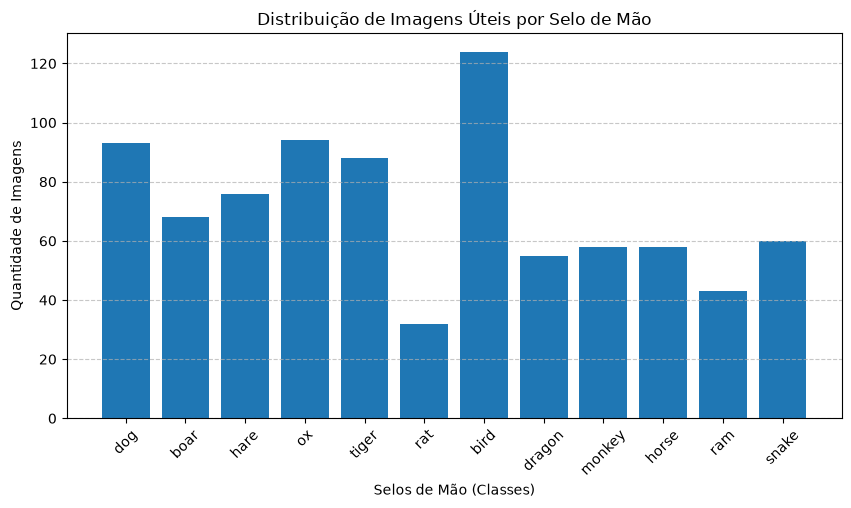

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(usable_dict.keys(), usable_dict.values())
plt.title('Distribuição de Imagens Úteis por Selo de Mão')
plt.xlabel('Selos de Mão (Classes)')
plt.ylabel('Quantidade de Imagens')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

A visualização do histograma acima evidencia a disparidade entre a frequência de diferentes selos de mão. O desbalanceamento é tal que algumas classes possuem o dobro de imagens úteis do que outras. Devido a esse fator e à baixa quantidade de imagens, a adição de novas imagens será realizada no dataset.

#### Relação entre atributos e alvo

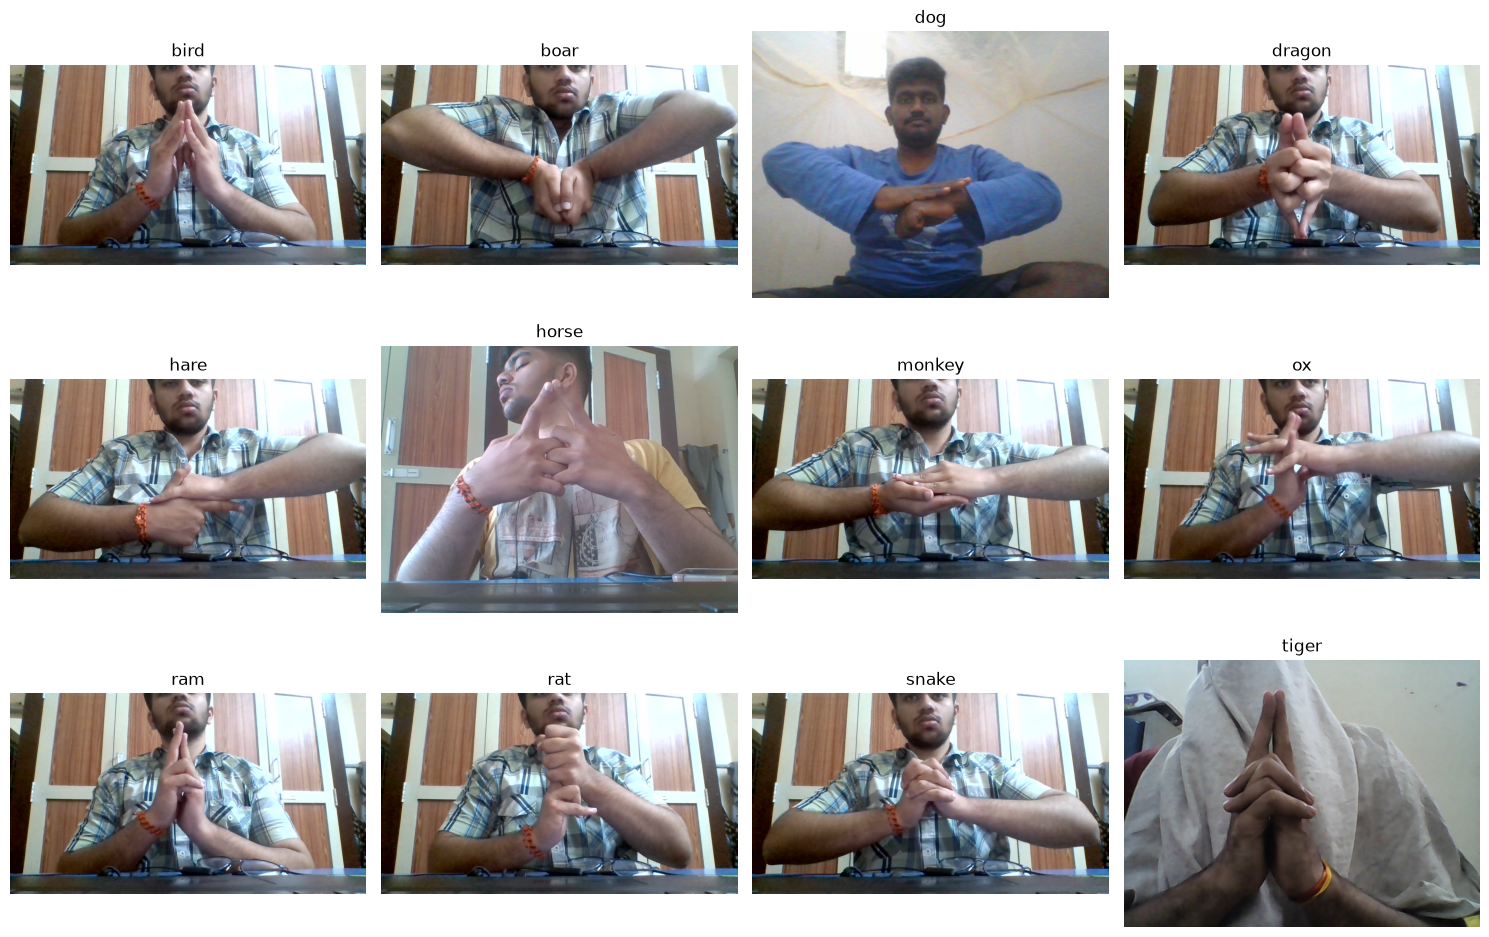

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, signal in enumerate(SIGNALS):
    signal_path = os.path.join(DATASET_PATH, signal)
    
    for img_name in os.listdir(signal_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(signal_path, img_name)
            img = Image.open(img_path)
            
            axes[i].imshow(img)
            axes[i].set_title(signal)
            axes[i].axis('off')
            break

plt.tight_layout()
plt.show()

Devido à natureza do dataset, os atributos preditivos consistem nas matrizes de pixels que compõem as imagens. Acima é possível observar uma imagem retirada do dataset de cada selo de mão. Essa plotagem demonstra a forma com que as imagens são colhidas, sendo o selo de mão ocupante de parte pequena da imagem.

#### Histogramas de intensidade de pixels

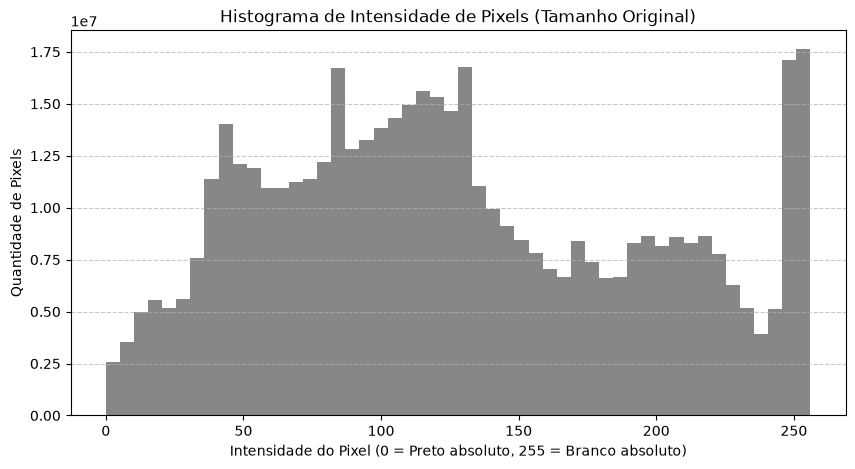

In [ ]:
import numpy as np

IMG_PER_SIGNAL = 50 

def pixels_intensity_histogram(size: int = 0):
    bins = 50
    histogram = np.zeros(bins)
    bar_limits = np.linspace(0, 256, bins + 1)

    for signal in SIGNALS:
        signal_path = os.path.join(DATASET_PATH, signal)
        
        if not os.path.exists(signal_path):
            continue
            
        count = 0
        for img_name in os.listdir(signal_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(signal_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        if size > 0: img.thumbnail((size, size)) 
                        gray_img = img.convert('L')
                        
                        pixels = np.array(gray_img).flatten()
                        
                        local_count, _ = np.histogram(pixels, bins=bar_limits)
                        histogram += local_count
                        
                except FileNotFoundError, OSError:
                    pass
                
                count += 1
                if count >= IMG_PER_SIGNAL:
                    break 

    plt.figure(figsize=(10, 5))

    bar_width = 256 / bins
    bar_center = bar_limits[:-1] + bar_width / 2

    plt.bar(bar_center, histogram, width=bar_width, color='dimgray', alpha=0.8)

    if size == 0:
        plt.title(f'Histograma de Intensidade de Pixels (Tamanho Original)')
    else:
        plt.title(f'Histograma de Intensidade de Pixels {size}x{size}')

    plt.xlabel('Intensidade do Pixel (0 = Preto absoluto, 255 = Branco absoluto)')
    plt.ylabel('Quantidade de Pixels')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

pixels_intensity_histogram()

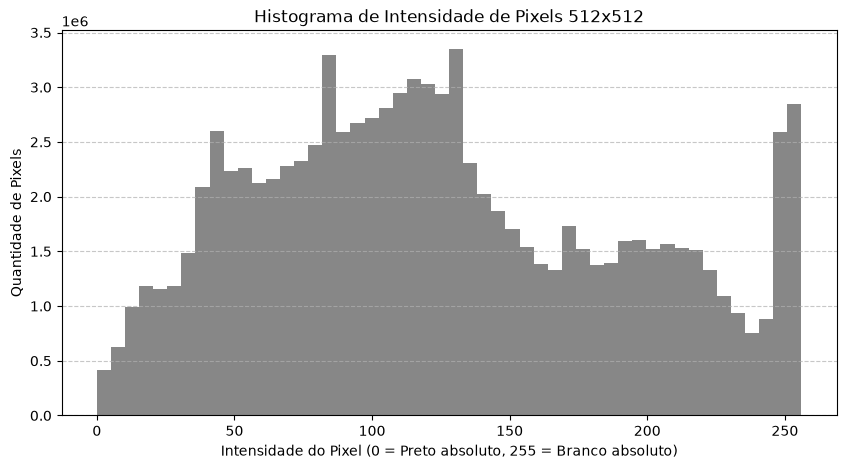

In [14]:
pixels_intensity_histogram(512)

Para os histogramas de intensidade de pixels, foi escolhida uma amostragem de 50 imagens por selo. Através deles, é possível notar que o dataset apresenta picos de superexposição (concentração de pixels próximos ao limite de 255), o que pode afetar a classificação dos selos de mão por parte dos modelos. Apesar disso, ao reduzir a resolução das imagens (segundo histograma), a concentração de pixels brancos diminuiu consideravelmente, o que pode contribuir para a mitigação desse problema.

# 4. Pré-processamento

## 4.1 Novas imagens

As imagens do dataset, além de escassas, apresentaram um baixo padrão de qualidade, sendo muitos delas frames consecutivos de um mesmo vídeo (quase nenhuma variação entre elas). Devido a isso, foi necessário adicionar novas imagens ao conjunto. Primeiro, a equipe desenvolveu um script que extrai imagens de um vídeo a cada 30 frames (veja o diretório `scripts/extracao`), já inserindo-as nas pastas corretas do dataset. Os vídeos foram gravados de forma com que diversas rotações e posições de um mesmo selo fossem obtidos. Depois, os integrantes da equipe gravaram vídeos fazendo os selos de mão em diferentes ambientes com diferentes iluminações. Também, foi indispensável a ajuda de outras pessoas na gravação desses vídeos, gerando diversidade suficiente para um modelo proveitoso. É fundamental destacar que houve revisão de cada uma das imagens, visando excluir a presença de registros borrados ou de baixa qualidade.

## 4.2 Redimensionamento das imagens

Antes de irem para o modelo, as imagens utilizadas foram redimensionadas para uma matriz fixa de pixels, com o objetivo de uniformizar os dados de entrada. Uma consequência positiva disso, é a normalização da intensidade dos pixels como visto anteriormente no histograma de intensidade de pixels.

## 4.3 Planificação das matrizes

As matrizes de pixels foram reorganizadas de modo que se tornassem matrizes unidimensionais, facilitando a utilização delas nos algoritmos requisitados.

# 5. Separação dos Dados

Os dados foram separados com a seguinte proporção: 80% para os dados de treinamento e 20% para os dados de teste. Essa proporção foi escolhida por ser a padrão para treinamento de classificação de imagens para a quantidade de dados que possuímos. 

Para seguir essa divisão, os dados são divididos em subpastas dentro dos sinais de mão, onde cada subpasta é nomeada como uma identificador único por vídeo de origem. Assim, 80% das subpastas são utilizadas para treinamento e 20% para teste. Isso evita que imagens de um mesmo vídeo sejam utilizadas para teste e treinamento simultânemante, o que poderia gerar uma taxa de acerto alta artificialmente devido à semelhança dos dados. 

# 6. Modelagem

# 7. Avaliação e Discussão